## Dataframes

In [ ]:
### ACTION

import numpy as np
import pandas as pd
from utils import *
import os

def load_dataframes_ratings():
    ds_ratings_path = get_dataset("arashnic/book-recommendation-dataset")

    books_df =pd.read_csv(os.path.join(ds_ratings_path, "Books.csv"),
                        dtype={"Year-Of-Publication": "string"})
    users_df =pd.read_csv(os.path.join(ds_ratings_path, "Users.csv"))
    ratings_df =pd.read_csv(os.path.join(ds_ratings_path, "Ratings.csv"))

    ratings_df["Book-Rating"] = ratings_df["Book-Rating"].astype(float)

    # rename fields
    books_df.rename(columns={'Book-Title': 'title'}, inplace=True)
    books_df.rename(columns={'Book-Author': 'author'}, inplace=True)
    books_df.rename(columns={'Year-Of-Publication': 'pub_year'}, inplace=True)

    # remove implicit 0 ratings
    ratings_df = ratings_df[ratings_df["Book-Rating"] != 0]

    return books_df, ratings_df, users_df

books_df, ratings_df, users_df = load_dataframes_ratings()

/home/barto/book-recommendation/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /home/barto/.cache/kagglehub/datasets/arashnic/book-recommendation-dataset/versions/3
Ratings.csv
Users.csv
recsys_taxonomy2.png
classicRec.png
DeepRec.png
Books.csv


In [3]:
### PREVIEW

print("books: ", books_df.shape)
print("users: ", users_df.shape)
print("explicit ratings: ", ratings_df.shape)

print(f"Rated books: {ratings_df['ISBN'].nunique()}")

print("Users: ", users_df.columns)
print()
print("Books: ", books_df.columns)
print()
print("Ratings: ", ratings_df.columns)

books:  (271360, 8)
users:  (278858, 3)
explicit ratings:  (433671, 3)
Rated books: 185973
Users:  Index(['User-ID', 'Location', 'Age'], dtype='str')

Books:  Index(['ISBN', 'title', 'author', 'pub_year', 'Publisher', 'Image-URL-S',
       'Image-URL-M', 'Image-URL-L'],
      dtype='str')

Ratings:  Index(['User-ID', 'ISBN', 'Book-Rating'], dtype='str')


#### Data cleaning
One book (author, title) can have multiple entries with different ISBNs based on different publishers. For the sake of recommender we can combine them into one, as books are likely rated based on the content. The books will be combined on the ISBN with the lowest alphabetical order. Also books can be added with multiple titles that are essentially the same but have some extra information like edition, or audio in paranthesis, these books will also be treated as one. This will mostly affect very popular titles, but these are the titles I will be using for benchmark.

In [4]:
### PREVIEW

print("Duplicit books: ")
print(books_df[books_df['title'].str.contains('Crime and Punishment', case=False, na=False)].head()[['title']])

Duplicit books: 
                                               title
5235   Crime and Punishment (Crime &amp; Punishment)
13853        Crime and Punishment (Penguin Classics)
14424             Crime and Punishment (Classics S.)
18393        Crime and Punishment (Penguin Classics)
20404     Crime and Punishment (Wordsworth Classics)


In [11]:
### ACTION

print("Books before: ", books_df.shape)
print("Ratings before: ", ratings_df.shape)

def merge_by_title(books_df, ratings_df):
    books_df = books_df.copy()
    ratings_df = ratings_df.copy()

    # use clean titles
    books_df['title_clean'] = books_df['title'].str.replace(r'\s*\([^)]*\)\s*$', '', regex=True)
    books_df['title'] = books_df['title_clean']
    books_df = books_df.drop(columns='title_clean')

    # use smallest ISBN when mapping title and author -> ISBN
    isbn_map = books_df.groupby(['title', 'author'], dropna=False)['ISBN'].min().reset_index()
    isbn_map = isbn_map.rename(columns={'ISBN': 'ISBN_merged'})

    isbn_to_merged = books_df.merge(isbn_map, on=['title', 'author'], how='left').set_index('ISBN')['ISBN_merged'].to_dict()

    books_df = books_df.merge(isbn_map, on=['title', 'author'], how='left')
    books_df = books_df.drop_duplicates(subset='ISBN_merged', keep='first')
    books_df['ISBN'] = books_df['ISBN_merged']
    books_df = books_df.drop(columns='ISBN_merged')

    ratings_df['ISBN'] = ratings_df['ISBN'].map(isbn_to_merged).fillna(ratings_df['ISBN'])
    ratings_df = ratings_df.groupby(['User-ID', 'ISBN'], as_index=False)['Book-Rating'].mean()

    return books_df, ratings_df

books_df, ratings_df = merge_by_title(books_df=books_df, ratings_df=ratings_df)

print("Books after: ", books_df.shape)
print("Ratings after: ", ratings_df.shape)

Books before:  (244499, 9)
Ratings before:  (432558, 3)
Books after:  (244392, 8)
Ratings after:  (432555, 3)


In [ ]:
### PREVIEW

print("Duplicit books: ")
print(books_df[books_df['title'].str.contains('Crime and Punishment', case=False, na=False)].head()[['title', 'author']])

Duplicit books: 
                                                   title                author
5235                                Crime and Punishment     Fyodor Dostoevsky
13853                               Crime and Punishment    Fyodor Dostoyevsky
34807            Crimen y Castigo / Crime and Punishment  Fyodor M. Dostoevsky
69618                               Crime and Punishment  Fyodor M. Dostoevsky
74047  Crime and Punishment: The Coulson Translation ...     Feodor Dostoevsky


#### Insight
Still some inconsistencies because The author names are spelled differently, but we will live with this.

## Data diagnostics

In [8]:
### PREVIEW

print("Share of users who have age data: ", 1.0-users_df["Age"].isna().mean())
print("Share of users who have Location data: ", 1.0-users_df["Location"].str.strip().eq("").mean())

Share of users who have age data:  0.6028014258152895
Share of users who have Location data:  1.0


#### Ratings per book

count    172154.000000
mean          2.512622
std           8.202961
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max         707.000000
Name: count, dtype: float64

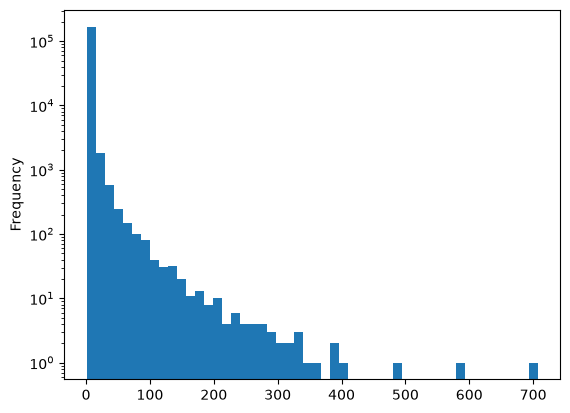

In [9]:
### PREVIEW

ratings_per_book = ratings_df["ISBN"].value_counts()
ratings_per_book.plot(kind="hist", bins=50, log=True)
ratings_per_book.describe()

#### Ratings per user

count    77805.000000
mean         5.559514
std         43.200869
min          1.000000
25%          1.000000
50%          1.000000
75%          3.000000
max       8251.000000
Name: count, dtype: float64

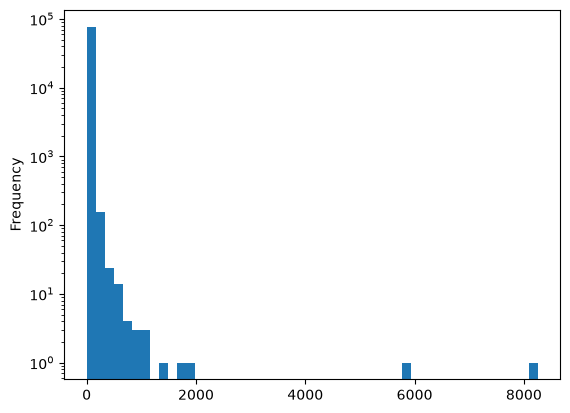

In [10]:
### PREVIEW

ratings_per_user = ratings_df["User-ID"].value_counts()
ratings_per_user.plot(kind="hist", bins=50, log=True)
ratings_per_user.describe()

#### Insight #1

Reviews per-user have higher deviation: few super users with mega amounts of ratings but vast majority of users don't rank at all. For the reviews per book, most books also have no review but it is slightly more balanced. The base task also only gives one favourite book -> with a single book as favourite, and most users having no reviews finding similar users is difficult. The super users can actually benefit the item-item relations. **Item-based > User based.** I assume here I won't be using user age and location data as I don't think it can provide interesting recommandations (very surface level, generic).

In [12]:
### ACTION

print(f"Books count before: {ratings_df['ISBN'].nunique()}")
print(f"Users count before: {ratings_df['User-ID'].nunique()}")

def filter_rankings_freq(df):
    """Filters out rows, to leave keep min ratings per book and min ratings per user"""
    df = df.copy()

    # filter out books and users with few ratings
    MIN_RATINGS_USER = 3
    MIN_RATINGS_BOOK = 1
    book_counts = df["ISBN"].value_counts()
    user_counts = df["User-ID"].value_counts()

    i = 0
    while True:
        i += 1
        old_size = len(df)

        user_counts = df["User-ID"].value_counts()
        df = df[df["User-ID"].isin(user_counts[user_counts >= MIN_RATINGS_USER].index)]

        book_counts = df["ISBN"].value_counts()
        df = df[df["ISBN"].isin(book_counts[book_counts >= MIN_RATINGS_BOOK].index)]

        if len(df) == old_size:
            break

    print(f"Iterations: {i}")

    return df

df_ratings_filtered = filter_rankings_freq(ratings_df)

print(f"Books remaining: {df_ratings_filtered['ISBN'].nunique()}")
print(f"Users remaining: {df_ratings_filtered['User-ID'].nunique()}")

Books count before: 172154
Users count before: 77805
Iterations: 2
Books remaining: 155179
Users remaining: 22565


#### Insight #2

For item-item relations to work I need books to have ideally ratings from many users, and also users to give ratings to many books. The ladder needs to be atlest 2 to establish a relation. Since the data is so sparse I will only limit to at least 1 rating per book, but users for 2 ratings. Not ideal, some recommendations will be coincidental cause 1 users who rated this book also happened to rate this one, not necessirly cause they are similar.

#### Rated books

In [ ]:
### PREVIEW

counts = df_ratings_filtered["ISBN"].value_counts()
result = books_df.set_index("ISBN").reindex(counts.index)[["title", "author"]]
result["num_ratings"] = counts.values
print(result.head())

print(f"Rated books without a title: {result["title"].isna().sum()}/{result.shape[0]}")

                                              title         author  \
ISBN                                                                 
0316666343                The Lovely Bones: A Novel   Alice Sebold   
0385504209                        The Da Vinci Code      Dan Brown   
0971880107                              Wild Animus   Rich Shapero   
0142001740                  The Secret Life of Bees  Sue Monk Kidd   
0439064864  Harry Potter and the Chamber of Secrets  J. K. Rowling   

            num_ratings  
ISBN                     
0316666343          497  
0385504209          381  
0971880107          334  
0142001740          302  
0439064864          298  
Rated books without a title: 29105/155215


#### Insight #3

A lot of rated books don't have a title in the our books database. This could be resolved by merginng with another books dataset, or fetching manually upon retrieval.

## Collaborative filtering, item-based

In [14]:
### ACTION

from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds
from sklearn.metrics.pairwise import cosine_similarity

class RecomModelCF:
    def __init__(self, books_df, k, raw=False):
        self.books_df = books_df.copy()
        self._k = k
        self._raw = raw

    def train(self, raitings_train_df):    
        user_c = raitings_train_df["User-ID"].astype("category") # user_id -> user_index
        book_c = raitings_train_df["ISBN"].astype("category") # book_isbn -> book_index
        # build a sparse matrix -> book rating at position (user_index, book_index)
        self.matrix = csr_matrix(
            (raitings_train_df["Book-Rating"], (user_c.cat.codes, book_c.cat.codes))
        )

        self.user_ids = user_c.cat.categories
        self.book_isbns = book_c.cat.categories

        if self._raw:
            return
        
        self.U, self.sigma, self.Vt = svds(self.matrix, k=self._k)

    def recommend(self, isbn, n=10):
        if self._raw:
            return self._recommend_raw(isbn, n)
        
        book_vectors = self.Vt.T

        idx = self.book_isbns.get_loc(isbn)

        sims = cosine_similarity(
            book_vectors[idx].reshape(1, -1),
            book_vectors
        )[0]

        return self._get_books(sims, n)

    def has_book(self, isbn):
        return isbn in self.book_isbns

    def _get_books(self, sims, n):
        top_idx = sims.argsort()[::-1][1:n+1]
        top_isbns = self.book_isbns[top_idx]

        result = self.books_df[self.books_df['ISBN'].isin(top_isbns)].copy()
        result['score'] = result['ISBN'].map(dict(zip(top_isbns, sims[top_idx])))
        result = result.sort_values('score', ascending=False)

        return result

    def _recommend_raw(self, isbn, n=10):
        idx = self.book_isbns.get_loc(isbn)

        sims = cosine_similarity(
            self.matrix[:, idx].T,
            self.matrix.T
        )[0]

        return self._get_books(sims, n)

#### Validation

The idea behind the validation process. 
- Get N users with >M 5+ ratings of books. This user likes these books.
- Then for each user hold out one book -> remove that user ranking on that book from train dataset.
- Per user: use the held out book to get recommendations on other books, the other books that user liked should be in the recommended books.
- Measure the recall rate. 

In [ ]:
### PREVIEW

def validate(model, seed=42):
    """ Trains model on rankings without held out books. Measures recall rate of held out books per user. """
    MIN_LIKED_BOOKS = 20
    MAX_LIKED_BOOKS = 1000
    N_RECALL = 10
    TEST_USERS = 1000

    # get users
    user_ids = (
        df_ratings_filtered[df_ratings_filtered["Book-Rating"] >= 7]
        .groupby("User-ID")["ISBN"]
        .nunique()
    )
    user_ids = user_ids[(user_ids >= MIN_LIKED_BOOKS) & (user_ids <= MAX_LIKED_BOOKS)]
    user_ids = user_ids.sample(min(TEST_USERS, len(user_ids)), random_state=seed).index

    # get held out books per user
    liked = df_ratings_filtered[
        (df_ratings_filtered["Book-Rating"] >= 7) &
        (df_ratings_filtered["User-ID"].isin(user_ids))
    ]
    held_out = (
        liked
        .groupby("User-ID")
        .sample(n=1, random_state=seed)
    )
    non_heldout = liked.merge(
        held_out[["User-ID", "ISBN"]],
        on=["User-ID", "ISBN"],
        how="left",
        indicator=True
    )
    non_heldout = non_heldout[
        non_heldout["_merge"] == "left_only"
    ].drop(columns="_merge")

    # remove held out books from the train set
    train_df = df_ratings_filtered.merge(
        held_out[["User-ID", "ISBN"]],
        on=["User-ID", "ISBN"],
        how="left",
        indicator=True
    )
    train_df = train_df[
        train_df["_merge"] == "left_only"
    ].drop(columns="_merge")

    # train model
    model.train(train_df)

    hits = 0
    tries = 0

    for user_id, group in non_heldout.groupby("User-ID"):
        held_out_isbn = held_out.loc[
            held_out["User-ID"] == user_id, "ISBN"
        ].iloc[0]

        other_isbns = set(group["ISBN"])

        # skip if held out book is not in the model
        if held_out_isbn not in model.book_isbns:
            continue

        recommended = model.recommend(
            isbn=held_out_isbn,
            n=N_RECALL
        )

        recommended_isbns = set(recommended["ISBN"])

        overlap = recommended_isbns & other_isbns

        tries += 1
        if overlap:
            hits += 1

    print(f"Hits: {hits}/{tries} [ {hits/tries} ]")

raw_model = RecomModelCF(books_df=books_df, k=0, raw=True)
print("raw model: ")
validate(raw_model, seed=42)

# TODO uncomment, slow
for k in [5, 7, 10, 12, 15, 20, 25, 50]:
    model = RecomModelCF(books_df=books_df, k=k)
    print(f"k = {k}")
    validate(model, seed=42)

raw model: 
Hits: 93/731 [ 0.12722298221614228 ]


#### Insight 5
The hit rate isn't too high, but that to be expected as it is just a proxy. It measures if the books that we know the user liked would be recommended to him. Where the real goal is to measure if the user would like the books that were recommended, which we can't measure directly. 

The SVD doesn't provide much of an advantage.

#### Manual validation

In [16]:
### PREVIEW

model_cf = RecomModelCF(books_df=books_df, k=0, raw=True)
model_cf.train(df_ratings_filtered)

SEARCH_ISBN = '0439136350'

print("Book: ")
print(books_df.loc[books_df['ISBN'] == SEARCH_ISBN][['title', 'author']])

recommendations = model_cf.recommend(isbn=SEARCH_ISBN, n=5)

print("Reccomandations: ")
print(recommendations[["title", "author"]])

Book: 
                                         title         author
3713  Harry Potter and the Prisoner of Azkaban  J. K. Rowling
Reccomandations: 
                                                  title         author
5230                Harry Potter and the Goblet of Fire  J. K. Rowling
3356            Harry Potter and the Chamber of Secrets  J. K. Rowling
2727              Harry Potter and the Sorcerer's Stone  J. K. Rowling
5299          Harry Potter and the Order of the Phoenix  J. K. Rowling
2085  Harry Potter and the Sorcerer's Stone (Harry P...  J. K. Rowling


## Content-based search
We will use another dataset, which provides books genres (tags: "fantasy", "romance"...) and description (short text describing the book).

In [31]:
### ACTION

def load_dataframes_CB():
    ds_info_path = get_dataset("abhijitdalal26/books-dataset-with-description-85k-books")

    books_info_df = pd.read_csv(os.path.join(ds_info_path, "books_dataset.csv"))
    print(books_info_df.shape)
    print(books_info_df.columns)

    # convert to ISBN10, drop if cannot convert
    import isbnlib
    def to_isbn10(isbn13):
        isbn13 = str(isbn13)
        if isbnlib.is_isbn13(isbn13):
            return isbnlib.to_isbn10(isbn13) or None
        return None

    books_info_df['ISBN'] = books_info_df['isbn13'].apply(to_isbn10)
    books_info_df = books_info_df.dropna(subset=['ISBN'])
    books_info_df = books_info_df.drop(columns=['isbn13'])
    books_info_df.insert(0, 'ISBN', books_info_df.pop('ISBN'))

    # fill missing ratings count with 0
    books_info_df['ratings_count'] = books_info_df['ratings_count'].fillna(0).clip(lower=0).astype(int)
    # fill missing ratings with mean rating
    avg_rating = books_info_df['avg_rating'].mean()
    books_info_df['avg_rating'] = books_info_df['avg_rating'].fillna(avg_rating).clip(lower=0.0, upper=5.0).astype(float)

    return books_info_df

books_info_df = load_dataframes_CB()

print(books_info_df.shape)
print(books_info_df.columns)

Path to dataset files: /home/barto/.cache/kagglehub/datasets/abhijitdalal26/books-dataset-with-description-85k-books/versions/1
books_dataset.csv
(85849, 13)
Index(['isbn13', 'title', 'author', 'description', 'genres', 'avg_rating',
       'ratings_count', 'publisher', 'format', 'pages', 'pub_year',
       'series_name', 'series_position'],
      dtype='str')
(85049, 13)
Index(['ISBN', 'title', 'author', 'description', 'genres', 'avg_rating',
       'ratings_count', 'publisher', 'format', 'pages', 'pub_year',
       'series_name', 'series_position'],
      dtype='str')


#### Data cleaning

In [27]:
print(books_info_df.iloc[10]["genres"])

['thriller', 'crime', 'historical fiction', 'fiction', 'paranormal', 'romance', 'fantasy', 'history', 'biography', 'mystery']


Genres are inconsistent, sometimes combined into 1 like "history, hisotrical ficion" -> we will split that into 2 genres "history" and "historical fiction" based on the comma.

Data needs to be cleaned, 

In [32]:
### ACTION

import ast
def prep_genres_CB(genres):
    """ Formats all genres into list[str]. Splits genres like "history, fiction" into "history" and "fiction". """
    if isinstance(genres, list):
        genre_list = genres
    elif type(genres) is not str or genres.strip() == "":
        return []
    else:
        try:
            genre_list = ast.literal_eval(genres)
            if not isinstance(genre_list, list):
                genre_list = [str(genre_list)]
        except (ValueError, SyntaxError):
            genre_list = [genres]

    result = set()
    for g in genre_list:
        result.update(part.strip().lower() for part in g.split(','))
    return list(result)

books_info_df['genres'] = books_info_df['genres'].apply(prep_genres_CB)

print(books_info_df.iloc[0]["genres"])

['thriller', 'crime', 'fiction', 'paranormal', 'romance', 'fantasy', 'mystery', 'young-adult']


#### Keep unique books by title and author
This time we will also concatante genres, and descriptions.

In [33]:
### ACTION

def merge_by_title_CB(df):
    df = df.copy()

    counts = df.groupby(['title', 'author'])['ISBN'].nunique()
    duplicates = counts[counts > 1]
    print(f"Total books: {df.shape[0]} books with duplicates: {len(duplicates)}")

    print("Books before: ", df.shape)

    # isbn to other same book isbns, keep smallest isbn
    isbn_map = df.groupby(['title', 'author'], dropna=False)['ISBN'].min().reset_index()
    isbn_map = isbn_map.rename(columns={'ISBN': 'ISBN_merged'})

    # merged genres
    genre_union = df.groupby(['title', 'author'], dropna=False)['genres'].agg(
        lambda lists: list(set().union(*lists))
    ).reset_index()
    genre_union = genre_union.rename(columns={'genres': 'genres_merged'})

    # merged descriptions
    desc_union = df.groupby(['title', 'author'], dropna=False)['description'].agg(
        lambda descs: [d for d in descs if isinstance(d, str)]
    ).reset_index()
    desc_union = desc_union.rename(columns={'description': 'description_merged'})

    # merged series_name (prefer non-null value if any book in the group has it)
    series_fill = df.groupby(['title', 'author'], dropna=False)['series_name'].agg(
        lambda vals: next((v for v in vals if pd.notna(v)), np.nan)
    ).reset_index()
    series_fill = series_fill.rename(columns={'series_name': 'series_name_filled'})

    # merge
    df = df.merge(isbn_map, on=['title', 'author'], how='left')
    df = df.merge(genre_union, on=['title', 'author'], how='left')
    df['genres'] = df['genres_merged']

    df = df.merge(desc_union, on=['title', 'author'], how='left')
    df['description'] = df['description_merged']

    df = df.merge(series_fill, on=['title', 'author'], how='left')
    df['series_name'] = df['series_name_filled']

    df = df.drop_duplicates(subset='ISBN_merged', keep='first')

    df['ISBN'] = df['ISBN_merged']

    df = df.drop(columns=['ISBN_merged', 'genres_merged', 'description_merged', 'series_name_filled'])

    return df

books_info_df = merge_by_title_CB(books_info_df)

print("Books after: ", books_info_df.shape)

Total books: 85049 books with duplicates: 4157
Books before:  (85049, 13)
Books after:  (78655, 13)


#### Assign quality score
Assign quality score to books using Bayesian weighted average, similar to IMDB. Quality is affected by the average ranking as well as the number of rankings. Prevents single ranking of 5.0 being higher than 10k rankings of 4.6.

In [37]:
### ACTION

def assing_quality_score_CB(df):
    df = df.copy()

    avg_rating = df['avg_rating'].mean()
    median_ratings_count = df['ratings_count'].median()

    def quality_score(row):
        v = row['ratings_count']
        R = row['avg_rating']
        m = median_ratings_count
        C = avg_rating

        return (v / (v + m)) * R + (m / (v + m)) * C

    df['quality_score'] = df.apply(quality_score, axis=1)

    return df

books_info_df = assing_quality_score_CB(books_info_df)

In [38]:
### PREVIEW
print("Highest quality books:")
print(books_info_df.sort_values('quality_score', ascending=False)[['title', 'author', 'quality_score']].head(10))

Highest quality books:
                                                  title             author  \
774                 Light Bringer (Red Rising Saga, #6)       Pierce Brown   
3602                     The Complete Calvin and Hobbes     Bill Watterson   
1290     Words of Radiance (The Stormlight Archive, #2)  Brandon Sanderson   
482            Harry Potter Boxset (Harry Potter, #1-7)       J.K. Rowling   
3070  Harry Potter Boxed Set, Books 1-5 (Harry Potte...       J.K. Rowling   
4684  It's a Magical World: A Calvin and Hobbes Coll...     Bill Watterson   
4188       Harry Potter Collection (Harry Potter, #1-6)       J.K. Rowling   
6111  There's Treasure Everywhere: A Calvin and Hobb...     Bill Watterson   
6394  The Authoritative Calvin and Hobbes: A Calvin ...     Bill Watterson   
3081                               Wintersteel (Cradle)         Will Wight   

      quality_score  
774        4.767313  
3602       4.765341  
1290       4.749944  
482        4.732046  
3070    

#### Genre-based: Filter minimum genre occurance, and minimum genres per book

In [ ]:
### ACTION

from collections import Counter

def filter_genre_freq_CB(df):
    """ Filter in loop to keep min genre freq and min genres count per book. """
    df = df.copy()

    MIN_GENRE_FREQ = 4
    MIN_GENRE_PER_BOOK = 2

    print(f"Books before: {df.shape[0]}")

    i = 0
    while True:
        i += 1

        genre_counts = Counter()
        df['genres'].apply(genre_counts.update)

        if i == 1:
            print(f"Unique genres before: {len(genre_counts)}")

        # filter genres by min frequency
        genres_to_keep = Counter({g: c for g, c in genre_counts.items() if c > MIN_GENRE_FREQ})
        genres_to_keep = set(genres_to_keep.keys())

        # Remove unused genres from books
        df['genres'] = df['genres'].apply(lambda genres: [x for x in genres if x in genres_to_keep])

        len_before = df.shape[0]

        # Filter books by min genre count
        df = df[df['genres'].apply(len) >= MIN_GENRE_PER_BOOK]

        # break if no change
        if df.shape[0] == len_before:
            break

    print(f"Unique genres after: {len(genre_counts)}")
    print(f"Iterations: {i}")
    print(f"Books after: {df.shape[0]}")
    return df

books_genre_df = filter_genre_freq_CB(books_info_df)

Books before: 78655
Unique genres before: 552
Unique genres after: 310
Iterations: 2
Books after: 63970


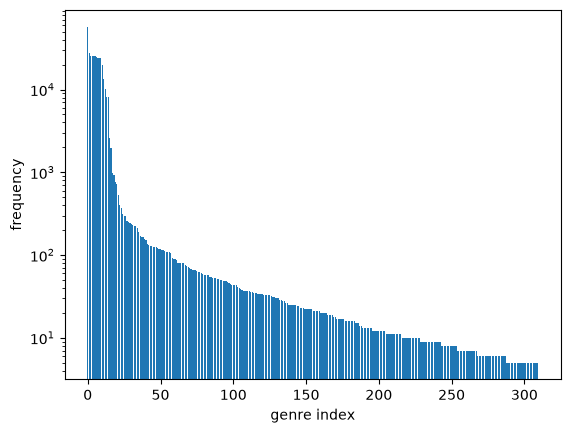

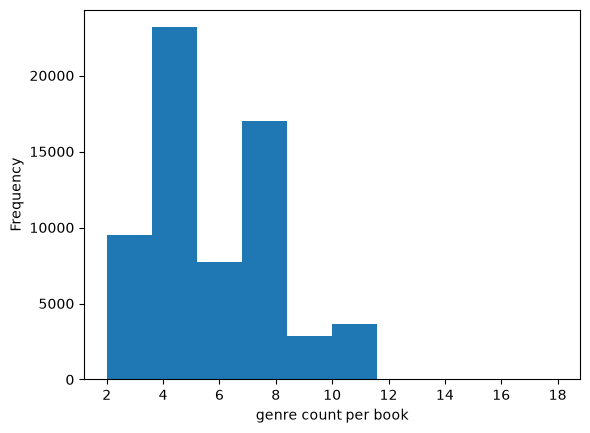

In [40]:
### PREVIEW

import matplotlib.pyplot as plt

genre_counts = Counter()
books_genre_df['genres'].apply(genre_counts.update)

counts = sorted(genre_counts.values(), reverse=True)
plt.bar(range(len(counts)), counts)
plt.xlabel("genre index")
plt.ylabel("frequency")
plt.yscale('log')
plt.show()

books_genre_df['genres'].apply(len).plot(kind='hist')
plt.xlabel("genre count per book")
plt.show()

#### Genre-based: Recommender
- Create a one-hot matrix, books x genres.
- Inverse Document Frequency: Weight the most popular genres less, so the match is more influenced by less popular / more niche genres.
- Genre cooccurance: Compute coocurance matrix of genres.
- SVD to reduce dimensions.
- Book embedding -> sum of genre embeddings.
- Cosine similarity on the books embeddings.

In [41]:
### ACTION

import numpy as np
from sklearn.decomposition import TruncatedSVD

class RecomModelGenreBased:
    def __init__(self, df, embedding_dim=50):
        df = df.copy()

        genres = set()
        df['genres'].apply(genres.update)
        self.genre_to_idx = {g: i for i, g in enumerate(genres)}

        df['genres_onehot'] = df['genres'].apply(self.genres_to_onehot)

        self.df = df.reset_index(drop=True)

        # one hot matrix
        onehot_matrix = np.stack(self.df['genres_onehot'].values)

        # IDF
        doc_freq = onehot_matrix.sum(axis=0) # how many books have each genre
        self.idf = np.log(len(self.df) / (doc_freq + 1)) # inverse document frequency
        weighted_matrix = onehot_matrix * self.idf

        # genre-genre co-occurrence matrix
        cooc = weighted_matrix.T @ weighted_matrix # (n_genres, n_genres)
        np.fill_diagonal(cooc, 0)

        # reduce to dense genre embeddings via SVD
        svd = TruncatedSVD(n_components=embedding_dim, random_state=42)
        genre_embeddings = svd.fit_transform(cooc)  # (n_genres, embedding_dim)

        # book vector = sum of its genres' embeddings
        self.matrix = onehot_matrix @ genre_embeddings  # (n_books, embedding_dim)

        self.isbn_to_row = {isbn: i for i, isbn in enumerate(self.df['ISBN'])}

        # precompute norms
        self.norms = np.linalg.norm(self.matrix, axis=1)

    def print_info(self):
        # print weights of most common and rarest genres
        weights = dict(zip(self.genre_to_idx.keys(), self.idf))
        sorted_weights = sorted(weights.items(), key=lambda x: x[1])
        print("Lowest (most common):", sorted_weights[:4])
        print("Highest (rarest):", sorted_weights[-4:])

    def genres_to_onehot(self, genres):
        vec = np.zeros(len(self.genre_to_idx))
        for g in genres:
            vec[self.genre_to_idx[g]] = 1
        return vec

    def has_book(self, isbn):
        return isbn in self.isbn_to_row

    def recommend(self, isbn, exclude_same_series=True, exclude_same_author=False, top_n=5):
        row = self.isbn_to_row[isbn]
        query_vec = self.matrix[row]

        
        query_norm = np.linalg.norm(query_vec)
        sims = self.matrix @ query_vec / (self.norms * query_norm + 1e-9)

        result = self.df[['ISBN', 'title', 'author', 'quality_score', 'series_name']].assign(similarity=sims)
        result = result.drop(row)

        if exclude_same_series:
            query_series = self.df.loc[row, 'series_name']
            if pd.notna(query_series):
                result = result[result['series_name'] != query_series]

        if exclude_same_author:
            query_author = self.df.loc[row, 'author']
            if pd.notna(query_author):
                result = result[result['author'] != query_author]

        result = result.sort_values(['similarity', 'quality_score'], ascending=False)
        return result.head(top_n)

model_genre_based = RecomModelGenreBased(books_genre_df, embedding_dim=100)

model_genre_based.print_info()

Lowest (most common): [('fiction', np.float64(0.10673362892944158)), ('romance', np.float64(0.8446282988108603)), ('historical fiction', np.float64(0.9145726525760975)), ('biography', np.float64(0.916759811704506))]
Highest (rarest): [('bande dessinée', np.float64(9.274410033216128)), ('scotland', np.float64(9.274410033216128)), ('portuguese literature', np.float64(9.274410033216128)), ('food writing', np.float64(9.274410033216128))]


#### Manual validation

In [42]:
### PREVIEW

popular_books = books_genre_df.sort_values('quality_score', ascending=False)[['ISBN', 'title']].head(10).sample(10)

for idx, row in popular_books.iterrows():
    print(f"Book: {row['title']}")
    r = model_genre_based.recommend(row['ISBN'])
    print("Recom: ")
    print(r['title'])
    print()

Book: Harry Potter Collection (Harry Potter, #1-6)
Recom: 
41980    The First Horror (99 Fear Street: The House of...
2913     Harry Potter Boxed Set, Books 1-5 (Harry Potte...
5896     Harry Potter and the Order of the Phoenix (Har...
3584                       The Darkest Hour (Warriors, #6)
14920    Last Stand of Dead Men (Skulduggery Pleasant, #8)
Name: title, dtype: str

Book: Words of Radiance (The Stormlight Archive, #2)
Recom: 
1358            A Memory of Light (Wheel of Time, #14)
681      Lover Awakened (Black Dagger Brotherhood, #3)
2868    Demon from the Dark (Immortals After Dark #10)
2241             The Blinding Knife (Lightbringer, #2)
5155                 Kiss of Snow (Psy-Changeling #10)
Name: title, dtype: str

Book: Harry Potter Boxset (Harry Potter, #1-7)
Recom: 
3019    Percy Jackson and the Olympians (Percy Jackson...
542        The House of Hades (The Heroes of Olympus, #4)
4954    Percy Jackson and the Olympians Boxed Set (Per...
195     The Last Olympian (Perc

## Description-based
- Create embeddings for books from descriptions using sentece embedder model.
- Use cosine similarity.

In [43]:
### ACTION

def prep_descriptions_CB(df):
    MIN_LEN = 16
    MAX_LEN = 384
    df = df.copy()

    print(f"Before: {df.shape[0]}")

    # keep only descriptions with length within a limit
    df['description'] = df['description'].apply(lambda x: [y for y in x if len(y.split()) >= MIN_LEN and len(y.split()) < MAX_LEN])

    # Keep only books with atleast one description
    df = df[df['description'].apply(len) > 0]

    # Keep only the first description, NOTE: the embedding could be averaged out from multiple descriptions if needed
    df['description'] = df['description'].apply(lambda x: str(x[0]))

    print(f"After: {df.shape[0]}")

    return df

books_desc_df = prep_descriptions_CB(books_info_df)

Before: 78655
After: 68529


In [44]:
### ACTION

from sentence_transformers import SentenceTransformer

class RecomModelDescBased():
    def __init__(self, df):
        self.df = df.copy()
        self.create_embeddings(self.df, overwrite=False)
        self.norms = np.linalg.norm(self.desc_embeddings, axis=1)

    def create_embeddings(self, df, overwrite):
        df = df.reset_index(drop=True)
        self.isbn_to_row = {isbn: i for i, isbn in enumerate(df['ISBN'])}
    
        if os.path.exists('description_embeddings.npy') and not overwrite:
            print("Using cached embeddings.")
            self.desc_embeddings = np.load('description_embeddings.npy')
            return
        
        self.embedder_model = SentenceTransformer('all-mpnet-base-v2', device='cuda')
        self.desc_embeddings = self.embedder_model.encode(df['description'].tolist(), show_progress_bar=True)

        np.save('description_embeddings.npy', self.desc_embeddings)

    def has_book(self, isbn):
        return isbn in self.isbn_to_row

    def recommend(self, isbn, exclude_same_series=True, exclude_same_author=False, top_n=5):
        row = self.isbn_to_row[isbn]
        query_vec = self.desc_embeddings[row]

        query_norm = np.linalg.norm(query_vec)
        sims = self.desc_embeddings @ query_vec / (self.norms * query_norm + 1e-9)

        result = self.df[['ISBN', 'title', 'author', 'quality_score', 'series_name']].assign(similarity=sims)
        result = result.drop(row)

        if exclude_same_series:
            query_series = self.df.loc[row, 'series_name']
            if pd.notna(query_series):
                result = result[result['series_name'] != query_series]
        
        if exclude_same_author:
            query_author = self.df.loc[row, 'author']
            if pd.notna(query_author):
                result = result[result['author'] != query_author]

        result = result.sort_values(['similarity', 'quality_score'], ascending=False)
        return result.head(top_n)

desc_model = RecomModelDescBased(books_desc_df)

print("Book: ")
print(books_desc_df.loc[books_desc_df['ISBN'] == '0439554934'][['title', 'author']])
print("Reccomandations: ")
print(desc_model.recommend('0439554934', exclude_same_series=True)[['title', 'author']])

Using cached embeddings.
Book: 
                                               title        author
1  Harry Potter and the Sorcerer's Stone (Harry P...  J.K. Rowling
Reccomandations: 
                                                   title           author
8672                      Man and Boy (Harry Silver, #1)     Tony Parsons
12610  MuggleNet.com's What Will Happen in Harry Pott...       Ben Schoen
1762                  Cold Days (The Dresden Files, #14)      Jim Butcher
15241                           The End of Harry Potter?   David Langford
38318  Mapping the World of Harry Potter: Science Fic...  Mercedes Lackey


## Combined recommender

In [45]:
from rapidfuzz import process, fuzz

class CombinedRecommender():
    def __init__(self, books_df, ratings_df, books_genre_df, books_desc_df):
        self.books_df = books_df.copy()
        self.ratings_df = ratings_df.copy()
        self.books_genre_df = books_genre_df.copy()
        self.books_desc_df = books_desc_df.copy()

        self.model_cf = RecomModelCF(books_df=books_df, k=0, raw=True)
        self.model_cf.train(ratings_df)
        self.model_genre = RecomModelGenreBased(df=books_genre_df, embedding_dim=100)
        self.model_desc = RecomModelDescBased(books_desc_df)

        rated_isbns = ratings_df["ISBN"].unique()
        self.availible_books_by_users = books_df[
            books_df["ISBN"].isin(rated_isbns)
        ][["ISBN", "title", "author"]].reset_index(drop=True)

        merged = pd.merge(
            books_genre_df[['ISBN', 'title', 'author']],
            books_desc_df[['ISBN', 'title', 'author']],
            on='ISBN', how='outer', suffixes=('', '_desc')
        )
        merged['title'] = merged['title'].fillna(merged['title_desc'])
        merged['author'] = merged['author'].fillna(merged['author_desc'])
        self.availible_books_by_content = merged[['ISBN', 'title', 'author']].reset_index(drop=True)

    def find_title(self, title, limit=5):
        def get_results(df):
            results = process.extract(
                title,
                df["title"],
                scorer=fuzz.WRatio,
                limit=limit
            )

            indices = [r[2] for r in results]

            return df.iloc[indices].assign(
                score=[r[1] for r in results]
            ).reset_index(drop=True)

        return {
            'by_users': get_results(self.availible_books_by_users),
            'by_content': get_results(self.availible_books_by_content)}

    def recommend_by_isbn(self, isbn, exclude_same_series = True, n=5):
        return {
            'by_users' : self.model_cf.recommend(isbn, n)[['title', 'author']] if self.model_cf.has_book(isbn) else [],
            'by_genre' : self.model_genre.recommend(isbn=isbn, exclude_same_series=exclude_same_series, top_n=n)[['title', 'author']] if self.model_genre.has_book(isbn) else [],
            'by_description' : self.model_desc.recommend(isbn=isbn, exclude_same_series=exclude_same_series, top_n=n)[['title', 'author']] if self.model_desc.has_book(isbn) else [],
        }

    def recommend_by_title(self, title, exclude_same_series=True, n=5):
        found_titles = self.find_title(title=title, limit=1)

        by_users_row = found_titles['by_users'].iloc[0] if len(found_titles['by_users']) > 0 else None
        by_users_book = by_users_row if by_users_row is not None and by_users_row['score'] >= 70 else None

        by_content_row = found_titles['by_content'].iloc[0] if len(found_titles['by_content']) > 0 else None
        by_content_book = by_content_row if by_content_row is not None and by_content_row['score'] >= 70 else None

        return {
            'by_users': (
                {
                    'found': by_users_book['title'],
                    'recommendations': self.model_cf.recommend(by_users_book['ISBN'], n)[['title', 'author']]
                }
                if by_users_book is not None
                else {'found': None, 'recommendations': []}
            ),
            'by_genre': (
                {
                    'found': by_content_book['title'],
                    'recommendations': self.model_genre.recommend(
                        isbn=by_content_book['ISBN'],
                        exclude_same_series=exclude_same_series,
                        top_n=n
                    )
                }
                if by_content_book is not None and self.model_genre.has_book(by_content_book['ISBN'])
                else {'found': None, 'recommendations': []}
            ),
            'by_desc': (
                {
                    'found': by_content_book['title'],
                    'recommendations': self.model_desc.recommend(
                        isbn=by_content_book['ISBN'],
                        exclude_same_series=exclude_same_series,
                        top_n=n)
                }
                if by_content_book is not None and self.model_desc.has_book(by_content_book['ISBN'])
                else {'found': None, 'recommendations': []}
            )
        }

In [46]:
combined_model = CombinedRecommender(books_df=books_df,
                                     ratings_df=df_ratings_filtered,
                                     books_genre_df=books_genre_df,
                                     books_desc_df=books_desc_df)

from pprint import pprint

#pd.set_option('display.max_colwidth', None)
#print(combined_model.find_title("Crime and Punishment", limit=3))
# pprint(combined_model.recommend_by_isbn(isbn='0439554934', exclude_same_series = True, n=3))
pprint(combined_model.recommend_by_title(title="Game of Thrones", n=3))

Using cached embeddings.
{'by_desc': {'found': 'A Game of Thrones (A Song of Ice and Fire, #1)',
             'recommendations':              ISBN                                         title  \
14540  0345536177        A Game of Thrones: Comic Book, Issue 2   
5408   0345536150        A Game of Thrones: Comic Book, Issue 1   
30184  0440423228  A Game of Thrones: The Graphic Novel, Vol. 2   

               author  quality_score                            series_name  \
14540  Daniel Abraham       4.274359  A Song of Ice and Fire Graphic Novels   
5408   Daniel Abraham       4.585532  A Song of Ice and Fire Graphic Novels   
30184  Daniel Abraham       4.109684  A Song of Ice and Fire Graphic Novels   

       similarity  
14540    0.790858  
5408     0.767600  
30184    0.709662  },
 'by_genre': {'found': 'A Game of Thrones (A Song of Ice and Fire, #1)',
              'recommendations':             ISBN                                       title          author  \
1074  0385340397 

TODO server... api